# Run multipoint files
- multiple channels per file with frequency multiplexing
- new paramter named multipoint_probe (=None for single point)

In [10]:
import numpy as np
ch = np.array([1,2,3]) #List the channel numbers being used
refs = np.array([1531.116,1537.397,1543.730,1550.116]) #List the reference frequencies for inputs on muxers
points = np.array([1,3,3]) #Number of points on each channel
offset = np.array([2,4,6,8])

5.0015625e-07


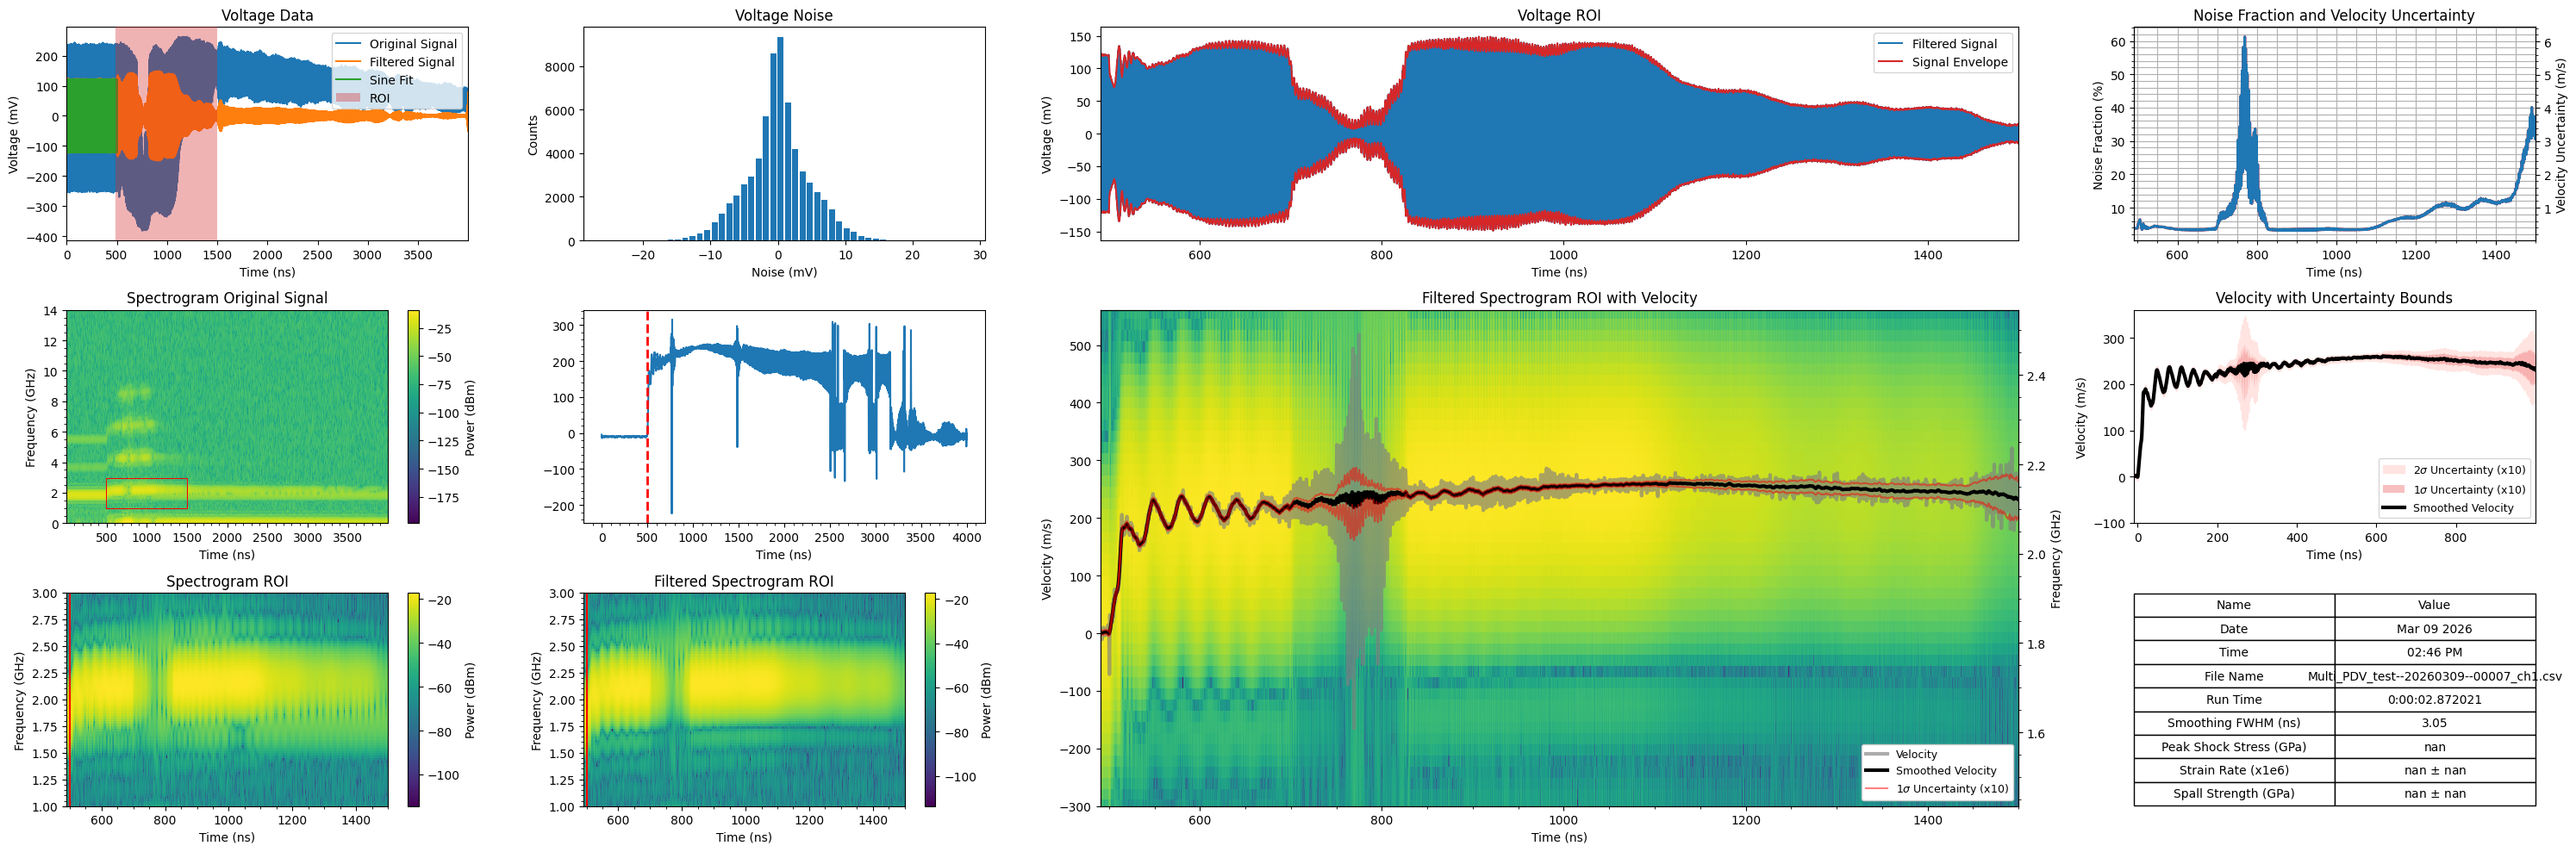

C:\Users\lucas\OneDrive - Johns Hopkins\Ramesh Lab - Research\Papers\MPDV\pdv_data\output_data\Multi_PDV_test--20260309--00007_ch1_probe10


,Date,Time,File Name,Run Time,Velocity at Max Compression,Time at Max Compression,Velocity at Max Tension,Time at Max Tension,Velocity at Recompression,Time at Recompression,...,Spall Strength,Spall Strength Uncertainty,Strain Rate,Strain Rate Uncertainty,Peak Shock Stress,Spect Time Res,Spect Freq Res,Spect Velocity Res,Signal Start Time,Smoothing Characteristic Time
0,Mar 09 2026,02:46 PM,Multi_PDV_test--20260309--00007_ch1.csv,0 days 00:00:02.872021,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.78125,25000000.0,19.3752,500.15625,3.049922e-09


(<Figure size 3000x1000 with 16 Axes>,
 {'Date': 'Mar 09 2026',
  'Time': '02:46 PM',
  'File Name': 'Multi_PDV_test--20260309--00007_ch1.csv',
  'Run Time': datetime.timedelta(seconds=2, microseconds=872021),
  'Velocity at Max Compression': nan,
  'Time at Max Compression': nan,
  'Velocity at Max Tension': nan,
  'Time at Max Tension': nan,
  'Velocity at Recompression': nan,
  'Time at Recompression': nan,
  'Carrier Frequency': np.float64(1822000000.0),
  'Spall Strength': nan,
  'Spall Strength Uncertainty': np.float64(nan),
  'Strain Rate': nan,
  'Strain Rate Uncertainty': np.float64(nan),
  'Peak Shock Stress': nan,
  'Spect Time Res': np.float64(7.812499999999999e-10),
  'Spect Freq Res': np.float64(25000000.0),
  'Spect Velocity Res': np.float64(19.3752),
  'Signal Start Time': np.float64(5.0015625e-07),
  'Smoothing Characteristic Time': np.float64(3.049921874999999e-09)})

In [8]:
%reset -f
from alpss_main import alpss_main
%matplotlib inline

# matplotlib.use('agg')

alpss_main(
    filepath=r"C:\Users\lucas\OneDrive - Johns Hopkins\Ramesh Lab - Research\Papers\MPDV\pdv_data\input_data\Multi_PDV_test--20260309--00007_ch1.csv",
    multipoint_probe = 10,
    save_data="yes",
    start_time_user='cusum', #cusum, explicit start time, or none
    header_lines=0,
    time_to_skip=2e-6,
    time_to_take=4e-6,
    t_before=10e-9,
    t_after=1000e-9,
    start_time_correction=0e-9,
    freq_min=1e9,
    freq_max=3e9,
    smoothing_window=1001,
    smoothing_wid=3,
    smoothing_amp=1,
    smoothing_sigma=1,
    smoothing_mu=0,
    pb_neighbors=400,
    pb_idx_correction=0,
    rc_neighbors=400,
    rc_idx_correction=0,
    sample_rate=128e9,
    nperseg=600,
    noverlap=500,
    nfft=5120,
    window="hann",
    blur_kernel=(5, 5),
    blur_sigx=0,
    blur_sigy=0,
    carrier_band_time=500e-9,
    cusum_offset=10,
    cusum_threshold=1000,
    cmap="viridis",
    uncert_mult=10,
    carrier_filter_type='gaussian_notch',  #sin_fit_subtract, gaussian_notch, or none
    t_fit_begin=15e-9,
    t_fit_end=300e-9,
    order=6,
    wid=0.04e9,
    lam=1550.016e-9,
    C0=10740,    
    density=3987,
    delta_rho=10,
    delta_C0=23,
    delta_lam=8e-18,
    theta=0,
    delta_theta=5,
    out_files_dir=(r"C:\Users\lucas\OneDrive - Johns Hopkins\Ramesh Lab - Research\Papers\MPDV\pdv_data\output_data"),
    display_plots="yes",
    spall_calculation="no",
    plot_figsize=(30, 10),
    plot_dpi=100,
)

Text(0.5, 0, 'Time (ns)')

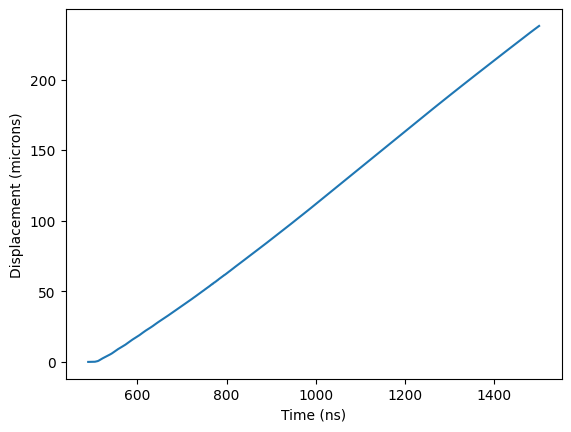

In [12]:
import matplotlib.pyplot as plt

data = np.genfromtxt(r"C:\Users\lucas\OneDrive - Johns Hopkins\Ramesh Lab - Research\Papers\MPDV\pdv_data\output_data\Multi_PDV_test--20260309--00007_ch1_probe10--displacement.csv", delimiter=',')

plt.plot(data[:,0]*1e9,data[:,1]*1e6)
plt.ylabel("Displacement (microns)")
plt.xlabel("Time (ns)")

In [ ]:
import pandas as pd
ch1 = pd.DataFrame([[1550.000,1550.016,10]], columns = ["tar_lam","ref_lam","probe_number"])
ch2 = pd.DataFrame([[1531.116,1531.132,6],[1537.397,1537.429,9],[1543.730,1543.778,15]], columns = ["tar_lam","ref_lam","probe_number"])
ch3 = pd.DataFrame([[1531.116,1531.132,3],[1537.397,1537.429,8],[1543.730,1543.778,19]], columns = ["tar_lam","ref_lam","probe_number"])

channels = {'ch1': ch1, 'ch2': ch2, 'ch3': ch3}
for name, channel in channels.items():
    for probe in range(len(channel)):
        ref_lam = channel["ref_lam"][probe]
        tar_lam = channel["tar_lam"][probe]
        probe_number = channel["probe_number"][probe]

        upshift = 3E8 / tar_lam - 3E8 / ref_lam #beat frequency offset in GHz
        freq_min = upshift - 0.5
        freq_max = upshift + 1.5
        print(upshift)
        

1.997898211091524
2.0474839656380937
4.061534391366877
6.042355877580121
2.0474839656380937
4.061534391366877
6.042355877580121


: 